# Image Compression and Reconstruction with SVD and Randomized SVD

This notebook implements the experiment described in the report section **Image Compression and Reconstruction**.

The goal is to compare:

1. **Classical truncated SVD**
2. **Randomized SVD (rSVD)** with different oversampling values

For each method and each target rank $k$, the notebook reconstructs the uploaded image and reports:

- the relative Frobenius residual

$$
\frac{\|A - \widehat{A}\|_F}{\|A\|_F}
$$

- the computation time required to obtain the low-rank reconstruction.

The randomized SVD method follows the framework introduced by Halko, Martinsson and Tropp in:

> Halko, N., Martinsson, P. G., and Tropp, J. A. (2011).  
> *Finding Structure with Randomness: Probabilistic Algorithms for Constructing Approximate Matrix Decompositions*.  
> SIAM Review, 53(2), 217--288. DOI: 10.1137/090771806.

## 1. Imports and configuration

This cell imports the required libraries. The notebook is designed to run on Google Colab.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image
from google.colab import files

# Reproducibility for randomized SVD
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Upload the image

Run the next cell and upload an image file from your computer.

The notebook converts the image to grayscale because the mathematical formulation of the experiment represents the image as a matrix $A \in \mathbb{R}^{m \times n}$.

Saving monkey.jpg to monkey (2).jpg
Uploaded image: monkey (2).jpg
Image matrix shape: (643, 736)
Pixel value range: [0.000, 1.000]


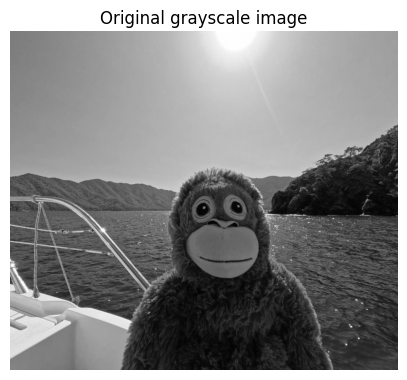

In [30]:
uploaded = files.upload()

if len(uploaded) == 0:
    raise RuntimeError("No image uploaded.")

image_path = next(iter(uploaded.keys()))
print(f"Uploaded image: {image_path}")

img = Image.open(image_path).convert("L")  # grayscale
A = np.asarray(img, dtype=np.float64) / 255.0

print(f"Image matrix shape: {A.shape}")
print(f"Pixel value range: [{A.min():.3f}, {A.max():.3f}]")

plt.figure(figsize=(5, 5))
plt.imshow(A, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

## 3. Parameters of the experiment

Here we define:

- `target_ranks`: the number of singular components used for the truncated reconstruction;
- `oversampling_values`: the values of the oversampling parameter $p$ used in randomized SVD;
- `power_iterations`: the number of power iterations used to improve rSVD accuracy.

The final plot will have:

- one row for classical SVD;
- one row for each randomized SVD configuration;
- one column for each value of $k$.

In [31]:
# At least 3 values of k are required. You can change them depending on the image size.
target_ranks = [5, 10, 25, 50, 100]

# Oversampling values p for randomized SVD.
# Each value produces a separate rSVD row in the final figure.
oversampling_values = [5, 10, 20]

# Number of power iterations q.
# q=0 is fastest; q=1 or q=2 is usually more accurate when singular values decay slowly.
power_iterations = 1

# Safety check: k+p must not exceed min(m, n).
max_rank_allowed = min(A.shape)
for k in target_ranks:
    if k + max(oversampling_values) > max_rank_allowed:
        raise ValueError(
            f"k + p is too large for the image size. "
            f"Got k={k}, max p={max(oversampling_values)}, but min(A.shape)={max_rank_allowed}."
        )

print("Target ranks k:", target_ranks)
print("Oversampling values p:", oversampling_values)
print("Power iterations q:", power_iterations)

Target ranks k: [5, 10, 25, 50, 100]
Oversampling values p: [5, 10, 20]
Power iterations q: 1


## 4. Classical truncated SVD

The classical truncated SVD computes

$$
A_k = U_k \Sigma_k V_k^T.
$$

For an image matrix, retaining only the first $k$ singular components gives a compressed approximation of the original image.

In [32]:
def truncated_svd_reconstruction(A, k):
    """
    Compute the classical truncated SVD reconstruction of matrix A.

    Parameters
    ----------
    A : np.ndarray
        Input matrix.
    k : int
        Target rank.

    Returns
    -------
    A_hat : np.ndarray
        Rank-k reconstruction.
    elapsed : float
        Computation time in seconds.
    """
    start = time.perf_counter()

    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    A_hat = (U[:, :k] * s[:k]) @ Vt[:k, :]

    elapsed = time.perf_counter() - start
    return np.clip(A_hat, 0.0, 1.0), elapsed

## 5. Randomized SVD implementation

The randomized SVD follows this structure:

1. Generate a random test matrix $\Omega \in \mathbb{R}^{n \times (k+p)}$.
2. Form the sample matrix $Y = A\Omega$.
3. Optionally apply power iterations:

$$
Y = (AA^T)^q A\Omega.
$$

4. Compute an orthonormal basis $Q$ for the range of $Y$.
5. Project $A$ onto the reduced space: $B = Q^T A$.
6. Compute the SVD of the smaller matrix $B$.
7. Reconstruct the approximate rank-$k$ matrix.

In [33]:
def randomized_svd_reconstruction(A, k, p=10, q=1, seed=42):
    """
    Compute a randomized SVD reconstruction of matrix A.

    Parameters
    ----------
    A : np.ndarray
        Input matrix of shape (m, n).
    k : int
        Target rank.
    p : int
        Oversampling parameter.
    q : int
        Number of power iterations.
    seed : int
        Random seed.

    Returns
    -------
    A_hat : np.ndarray
        Approximate rank-k reconstruction.
    elapsed : float
        Computation time in seconds.
    """
    rng = np.random.default_rng(seed)
    m, n = A.shape
    ell = k + p

    start = time.perf_counter()

    # Random test matrix
    Omega = rng.standard_normal(size=(n, ell))

    # Randomized range finder
    Y = A @ Omega

    # Power iterations improve accuracy when singular values decay slowly
    for _ in range(q):
        Y = A @ (A.T @ Y)

    # Orthonormal basis for sampled range
    Q, _ = np.linalg.qr(Y, mode="reduced")

    # Project original matrix into the reduced subspace
    B = Q.T @ A

    # Deterministic SVD on the small matrix B
    U_tilde, s, Vt = np.linalg.svd(B, full_matrices=False)

    # Recover approximate left singular vectors
    U = Q @ U_tilde

    # Truncate to target rank k
    A_hat = (U[:, :k] * s[:k]) @ Vt[:k, :]

    elapsed = time.perf_counter() - start
    return np.clip(A_hat, 0.0, 1.0), elapsed

## 6. Error metric

The residual used in the plot is the relative Frobenius error:

$$
E_{rel} = \frac{\|A - \widehat{A}\|_F}{\|A\|_F}.
$$

Lower values indicate better reconstruction quality.

In [34]:
def relative_frobenius_error(A, A_hat):
    """
    Compute the relative Frobenius reconstruction error.
    """
    return np.linalg.norm(A - A_hat, ord="fro") / np.linalg.norm(A, ord="fro")

## 7. Run all experiments

This cell computes all reconstructions.

Rows in the final plot are:

1. classical SVD;
2. rSVD with $p=5$;
3. rSVD with $p=10$;
4. rSVD with $p=20$.

Columns correspond to the selected values of $k$.

In [35]:
results = []

# Classical SVD row
for k in target_ranks:
    A_hat, elapsed = truncated_svd_reconstruction(A, k)
    error = relative_frobenius_error(A, A_hat)
    results.append({
        "method": "SVD",
        "k": k,
        "p": None,
        "q": None,
        "image": A_hat,
        "error": error,
        "time": elapsed,
    })

# Randomized SVD rows
for p in oversampling_values:
    for k in target_ranks:
        A_hat, elapsed = randomized_svd_reconstruction(
            A,
            k=k,
            p=p,
            q=power_iterations,
            seed=RANDOM_SEED,
        )
        error = relative_frobenius_error(A, A_hat)
        results.append({
            "method": f"rSVD, p={p}, q={power_iterations}",
            "k": k,
            "p": p,
            "q": power_iterations,
            "image": A_hat,
            "error": error,
            "time": elapsed,
        })

print("Completed experiments:", len(results))

Completed experiments: 20


## 8. Final reconstruction plot

The following plot is the main output of the experiment.

- Rows correspond to the methods.
- Columns correspond to the number of retained components $k$.
- Each subplot reports the relative residual and computation time.

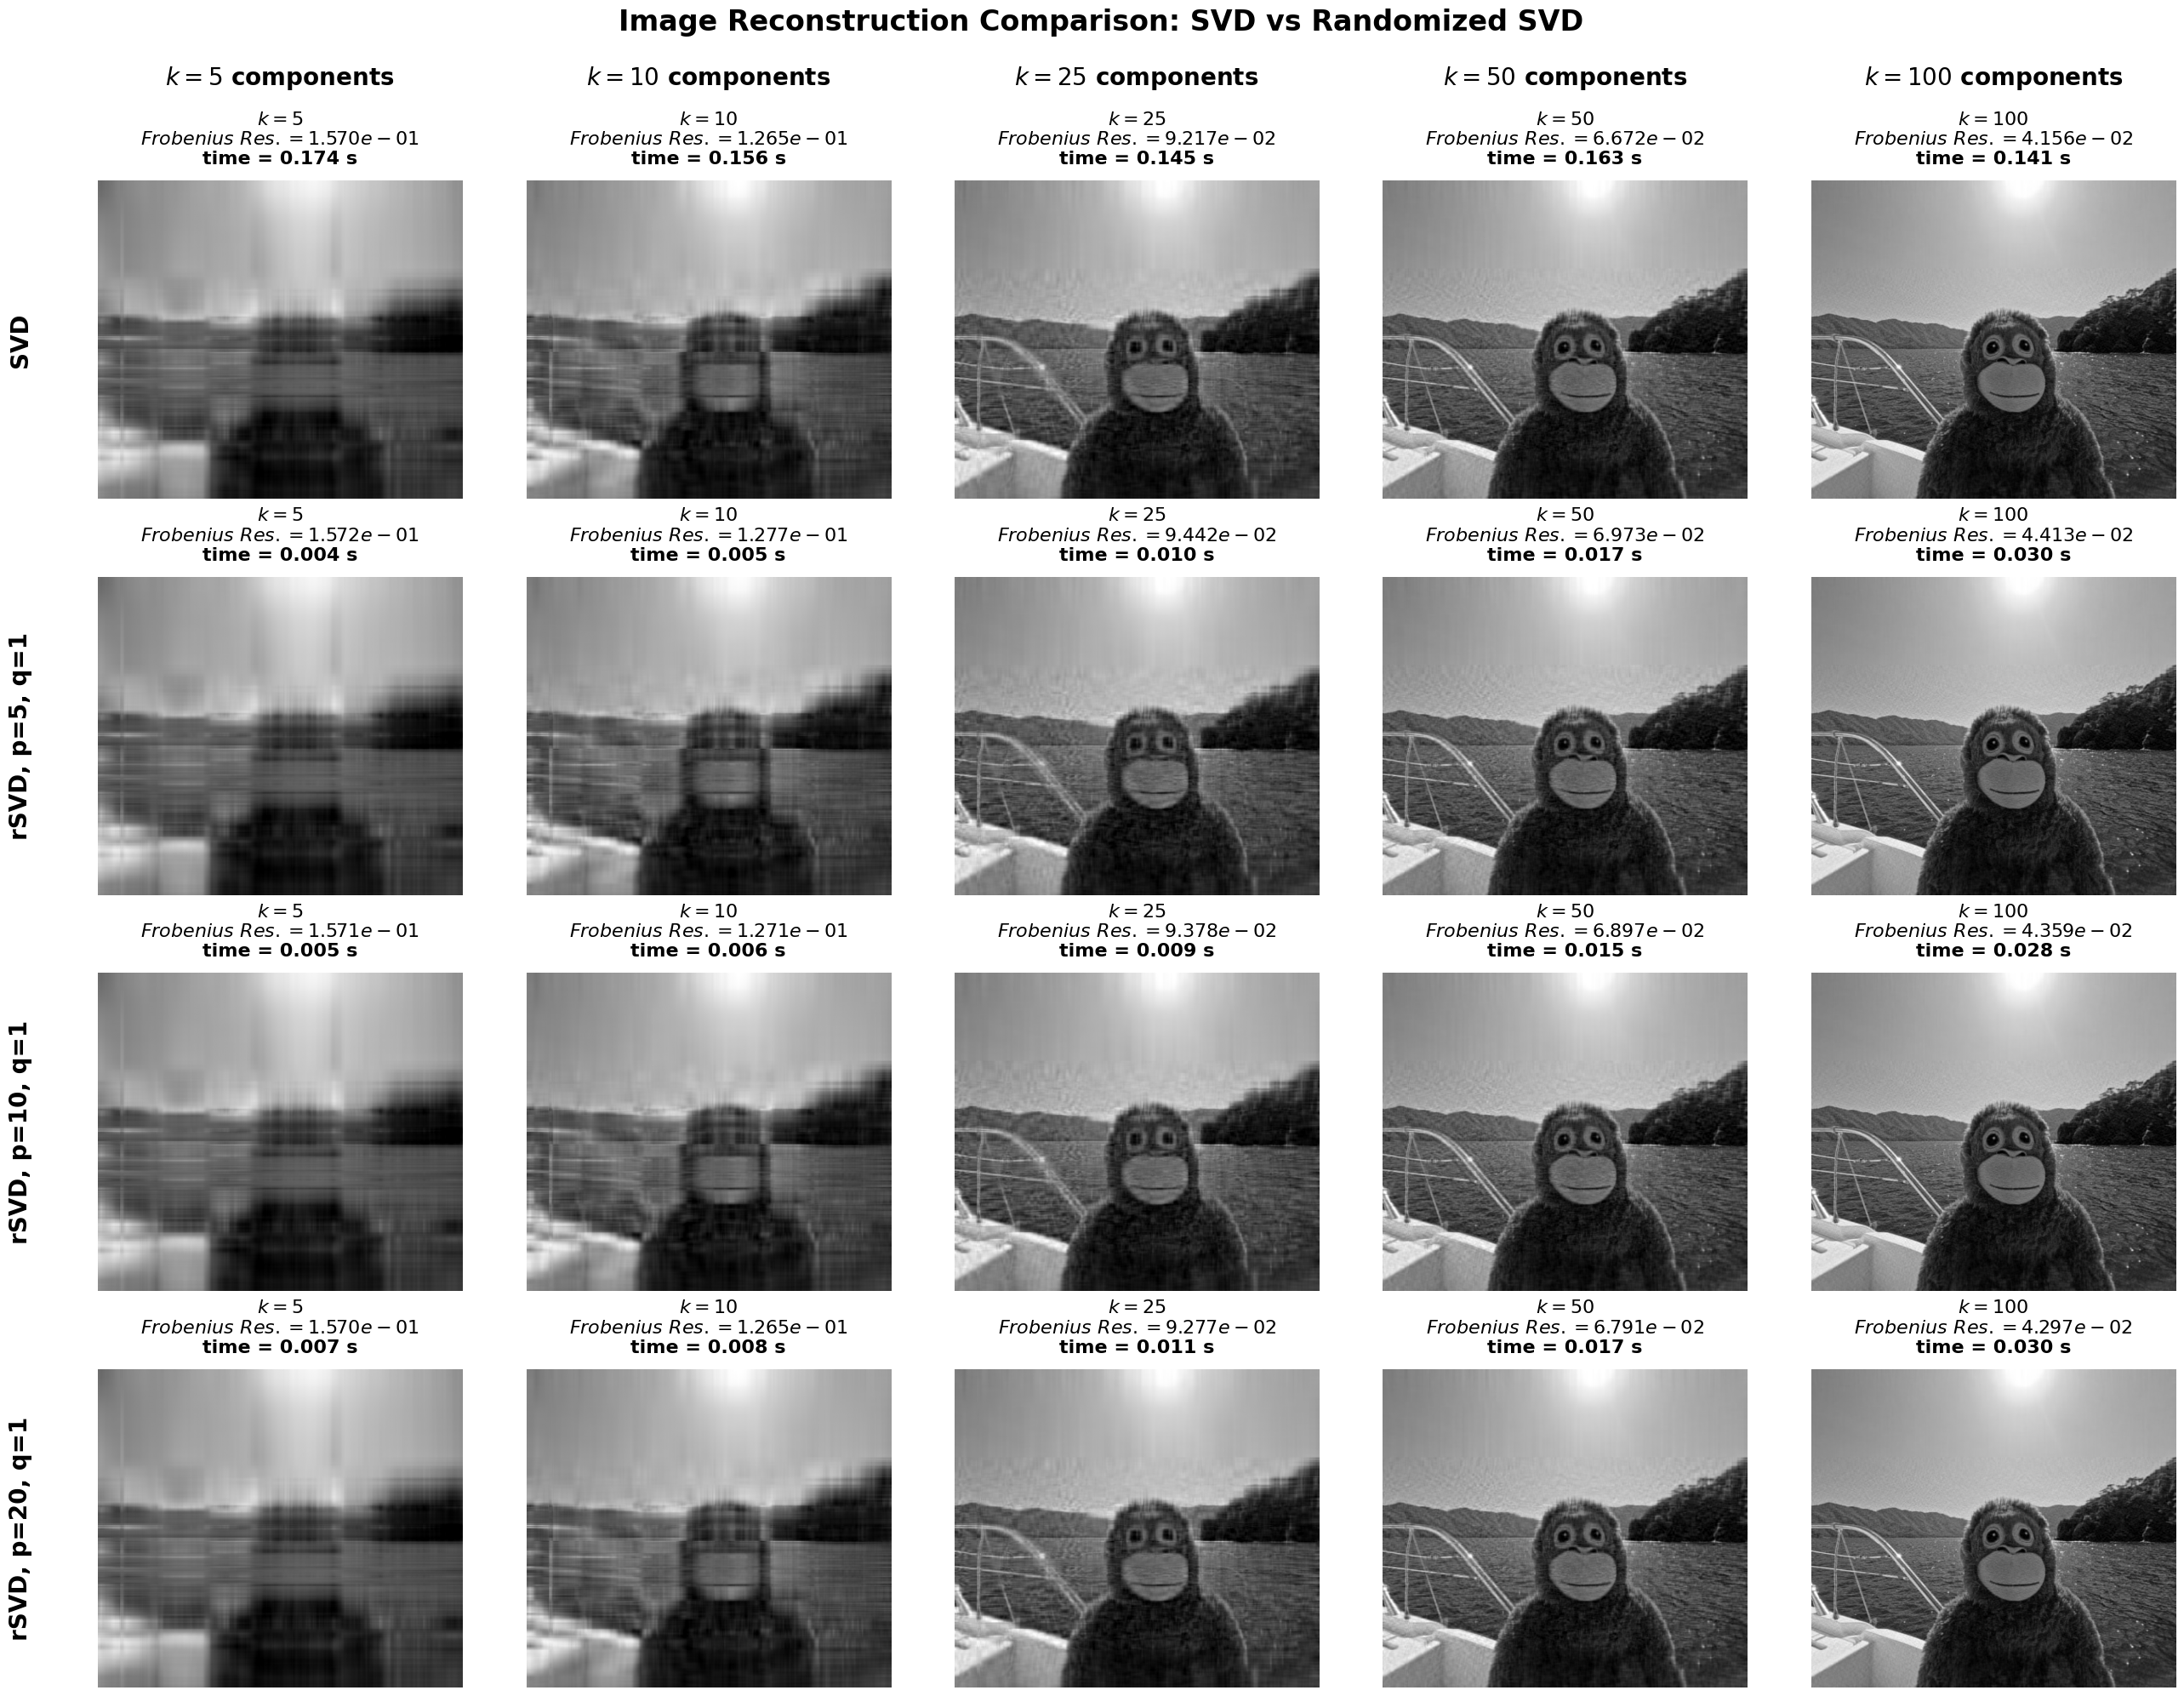

In [36]:
methods = ["SVD"] + [f"rSVD, p={p}, q={power_iterations}" for p in oversampling_values]
n_rows = len(methods)
n_cols = len(target_ranks)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.2 * n_cols, 4.8 * n_rows),
    constrained_layout=True
)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

for i, method in enumerate(methods):
    for j, k in enumerate(target_ranks):
        ax = axes[i, j]
        item = next(r for r in results if r["method"] == method and r["k"] == k)

        ax.imshow(item["image"], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

        title = (
            rf"$k={k}$"
            "\n"
            rf"$Frobenius \ Res. = {item['error']:.3e}$"
            "\n"
            rf"time = {item['time']:.3f} s"
        )

        ax.set_title(title, fontsize=16, fontweight="bold", pad=14)

# Column headers
for j, k in enumerate(target_ranks):
    axes[0, j].text(
        0.5, 1.28,
        rf"$k={k}$ components",
        transform=axes[0, j].transAxes,
        ha="center",
        va="bottom",
        fontsize=20,
        fontweight="bold"
    )

# Row labels
for i, method in enumerate(methods):
    axes[i, 0].text(
        -0.18, 0.5,
        method,
        transform=axes[i, 0].transAxes,
        ha="right",
        va="center",
        rotation=90,
        fontsize=20,
        fontweight="bold"
    )

fig.suptitle(
    "Image Reconstruction Comparison: SVD vs Randomized SVD",
    fontsize=24,
    fontweight="bold",
    y=1.03
)

plt.show()

In [37]:
fig.savefig("svd_rsvd_image_reconstruction.pdf", bbox_inches="tight")

## 9. Numerical summary table

The table below summarizes the residual and computation time for each method and each rank.

In [38]:
import pandas as pd

summary = pd.DataFrame([
    {
        "method": r["method"],
        "k": r["k"],
        "oversampling_p": r["p"],
        "power_iterations_q": r["q"],
        "relative_frobenius_residual": r["error"],
        "time_seconds": r["time"],
    }
    for r in results
])

summary

,method,k,oversampling_p,power_iterations_q,relative_frobenius_residual,time_seconds
0,SVD,5,NaN,NaN,0.156978,0.173871
1,SVD,10,NaN,NaN,0.126452,0.156268
2,SVD,25,NaN,NaN,0.092171,0.144664
3,SVD,50,NaN,NaN,0.066722,0.163184
4,SVD,100,NaN,NaN,0.041562,0.140786
5,"rSVD, p=5, q=1",5,5.0,1.0,0.157195,0.004427
6,"rSVD, p=5, q=1",10,5.0,1.0,0.127675,0.005235
7,"rSVD, p=5, q=1",25,5.0,1.0,0.094416,0.009860
8,"rSVD, p=5, q=1",50,5.0,1.0,0.069731,0.016506
9,"rSVD, p=5, q=1",100,5.0,1.0,0.044128,0.030004


## 10. Oversampling error analysis

This cell isolates the influence of the oversampling parameter $p$.

For each fixed rank $k$, we compare the relative residual obtained by randomized SVD for different values of $p$.

This is useful for the report because the practical focus of the project is the analysis of oversampling errors.

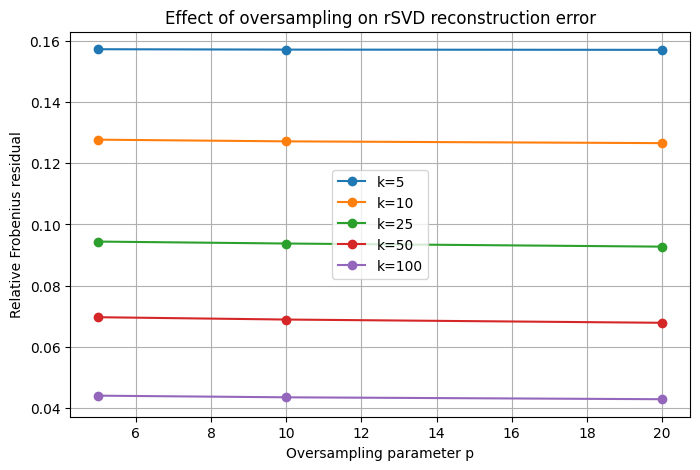

In [39]:
plt.figure(figsize=(8, 5))

for k in target_ranks:
    subset = summary[(summary["method"].str.startswith("rSVD")) & (summary["k"] == k)]
    plt.plot(
        subset["oversampling_p"],
        subset["relative_frobenius_residual"],
        marker="o",
        label=f"k={k}",
    )

plt.xlabel("Oversampling parameter p")
plt.ylabel("Relative Frobenius residual")
plt.title("Effect of oversampling on rSVD reconstruction error")
plt.legend()
plt.grid(True)
plt.show()